In [23]:
import numpy as np
import utils_COMBINE as uc
import matplotlib.pyplot as plt
from pathlib import Path
import utils as ut
import os

model = "results/RedSecMar_SubAln_0/RedSecMar_SubAln_0_ModelSBM_N_chains500_N_iter1000_Param_initzero_k_MCMC5000_lambda_J0.01_lambda_h0_m1_theta0.15_N_Av1_R0.npy"
alphabet_aa = '-ACDEFGHIKLMNPQRSTVWY'

In [2]:
pos = np.array(['16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '37', '37a', '37b', '37c', '37d', '37e', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '61a', '61b', '61c', '61d', '61e', '61f', '61g', '62', '63', '64', '66', '67', '68', '69', '70', '71', '72', '73', '74', '74a', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '96a', '96b', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '121a', '122', '123', '124', '125', '125a', '125b', '125c', '127', '128', '129', '130', '130a', '132', '133', '133a', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '148a', '148b', '148c', '148d', '149', '150', '151', '152', '153', '154', '155', '156', '157', '158', '159', '160', '161', '162', '163', '164', '165', '166', '167', '168', '169', '170', '171', '172', '173', '173a', '173b', '174', '175', '176', '177', '178', '179', '180', '181', '182', '183', '184', '184A', '185', '186', '187', '188', '188A', '189', '190', '191', '192', '193', '194', '195', '196', '197', '198', '199', '200', '201', '202', '202a', '202b', '202c', '202d', '202e', '203', '204', '209', '210', '211', '212', '213', '214', '215', '216', '217', '217a', '217b', '219', '220', '221', '221A', '222', '223', '224', '225', '226', '227', '228', '229', '230', '231', '232', '233', '234', '235', '236', '237', '238', '239', '240', '241', '242', '243', '244', '245', '245a', '245b', '245c'])

In [4]:
red_sector = [224,197,239,237,225,227,186,200,189,228,190,194,2,229,195,231,164,88,183,222,107,23,21]
red_sector = sorted(red_sector)

In [11]:
rat_trypsin = 'IVGGYTCQENSVPYQVSLNS-----GYHFCGGSLINDQWVVSAAHCYKS-------RIQVRLGEHNIN-VLEGNEQFVNAAKIIKHPNFDR--KTLNNDIMLIKLSSPVKLNARVATV-ALPS---SCAP-AG-TQCLISGWGNTLSSG----VNEPDLLQCLDAPLLPQADCEASYP--GKITDNMVCVGFLEGGKDSCQGDSGGPVVCN-----GELQGIVSWGY--GCALPDNPGVYTKVCNYVDWIQDTIAAN---'
rat_trypsin_red_sector_list = np.array([s for s in rat_trypsin])[red_sector]
rat_trypsin_red_sector = "".join(list(rat_trypsin_red_sector_list))

pos_red = pos[red_sector]

In [20]:
pos_red

array(['18', '37b', '37d', '94', '111', '160', '177', '180', '183', '184',
       '187', '188', '189', '192', '213', '215', '216', '217a', '217b',
       '219', '221', '226', '228'], dtype='<U4')

In [ ]:
12, 21

In [15]:
J = np.load(model, allow_pickle=True).item()['J']

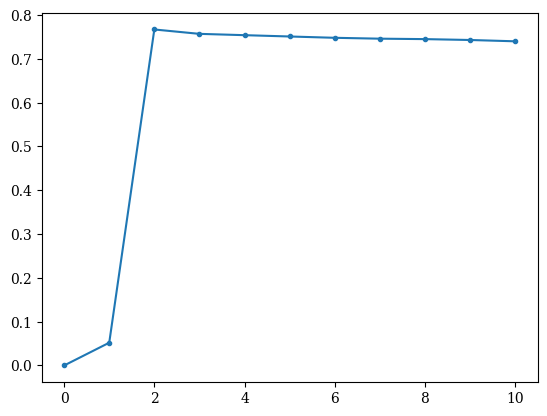

In [38]:
plt.plot(np.load(model, allow_pickle=True).item()['J_norm'].ravel(), '.-')

In [18]:
J.shape

(23, 23, 21, 21)

In [21]:
def DDE_189_226(J):
    #returns all the DDEs for compensating the D189S insertion on C.T.
    DDEs = -J[12,21,16,:] + np.outer(J[12,21,16,6], np.ones(21)) + J[12,21,3,:] - np.outer(J[12,21,3,6], np.ones(21))
    return DDEs

In [30]:
DDE = DDE_189_226(J).ravel()

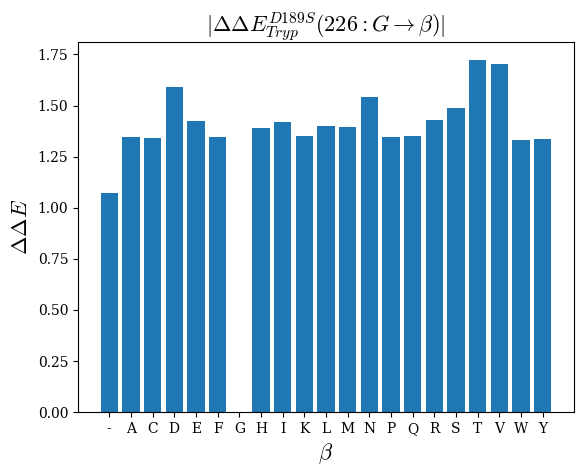

In [39]:
from config import CODE
plt.rcParams['mathtext.fontset'] = 'cm'        # use Computer Modern
plt.rcParams['font.family'] = 'serif' 
plt.bar(np.arange(21), np.abs(DDE))
plt.title(r'$|\Delta \Delta E_{Tryp}^{D189S}(226:G \rightarrow \beta)|$', fontsize = 16)
plt.xlabel(r'$\beta$' , fontsize = 16)
plt.ylabel(r'$\Delta \Delta E$' , fontsize = 16)

#highlighting S and T
#plt.axhline(np.abs(DDE[16]) , linestyle = ':', color = 'red')
#plt.axhline(np.abs(DDE[17]) , linestyle = ':', color = 'blue')

plt.xticks(ticks= np.arange(21), labels=CODE)
plt.show()

In [13]:
CompMut_DDE = uc.Propose_Mutation_DDE2(
    model,
    5,
    [('S','189')],
    POS_ALIGN=pos_red,
    SEQ_REF=rat_trypsin_red_sector)

Mutation 2: G226T   ΔΔE = -1.7223822341515804
Mutation 3: Y228F   ΔΔE = -2.7349199351021074
Mutation 4: A221N   ΔΔE = -2.6614460700322935
Mutation 5: -217aS   ΔΔE = -2.736158426749674
Mutation 6: -217bL   ΔΔE = -3.8175371395669275


In [46]:
list_of_ddes = []
for i in range(10):
    model_fn = f"results/RedSecMar_SubAln_{i}/RedSecMar_SubAln_{i}_ModelSBM_N_chains500_N_iter1000_Param_initzero_k_MCMC5000_lambda_J0.01_lambda_h0_m1_theta0.15_N_Av1_R0.npy"
    model = np.load(model_fn, allow_pickle=True).item()
    J = model['J']
    DDE = DDE_189_226(J).ravel()
    list_of_ddes.append(DDE)

means = np.abs(np.mean(np.array(list_of_ddes), axis=0))
stds = np.std(np.array(list_of_ddes), axis=0) / np.sqrt(10)

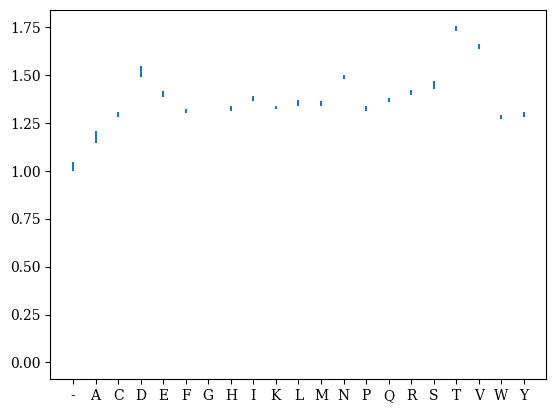

In [54]:
plt.figure()
plt.errorbar(x=np.arange(21), y=means, yerr=stds, ls='')
plt.xticks(ticks= np.arange(21), labels=CODE)
plt.show()